In [ ]:
# =================================================================
# 1. 환경 설정 및 라이브러리 설치
# =================================================================
!pip install roboflow ultralytics

import os
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from google.colab import drive
from roboflow import Roboflow
from ultralytics import YOLO

# 경로 설정
drive.mount('/content/drive')
DRIVE_SAVE_PATH = '/content/drive/MyDrive/food_yolo_project/train_results'
LAST_MODEL_PATH = f"{DRIVE_SAVE_PATH}/weights/last.pt"
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

# =================================================================
# 2. 데이터셋 다운로드 (Roboflow)
# =================================================================
rf = Roboflow(api_key="YZQwEreU5K2zX3jXN4W2")
project = rf.workspace("s-workspace-sqibd").project("finalfood")
dataset = project.version(1).download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 136.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings w

Extracting Dataset Version Zip to finalFood-1 in yolov8:: 100%|██████████| 33867/33867 [00:21<00:00, 1559.11it/s]


In [ ]:
# =================================================================
# 3. 모델 로드 및 학습 
# =================================================================
if os.path.exists(LAST_MODEL_PATH):
    print("\n🔄 [TRANSFER] 기존 가중치를 불러와 설정을 재정의하여 학습합니다!")
    # 지능은 가져오되, 깨진 설정 기록은 무시하고 새로 세팅합니다.
    model = YOLO(LAST_MODEL_PATH)

    epochs = 30 # 목표 에폭 다시 지정

    # resume=True를 빼고, 다시 데이터와 설정을 명시해줍니다.
    results = model.train(
        data=f"{dataset.location}/data.yaml", # 163종 음식 데이터셋 다시 지정
        epochs=epochs,                            
        patience=10,
        imgsz=640,
        batch=16,
        optimizer='AdamW',
        lr0=0.001,
        project='runs/detect',
        name='train_v2_upgraded',
        exist_ok=True
    )



🔄 [TRANSFER] 기존 가중치를 불러와 설정을 재정의하여 학습합니다!
Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/finalFood-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/food_yolo_project/train_results/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_v2_u


⚠️ 결과 폴더를 찾을 수 없습니다: /content/runs/detect/train_v2_upgraded
👉 학습이 완료되었는지, 폴더 이름이 바뀌지 않았는지 확인하세요.


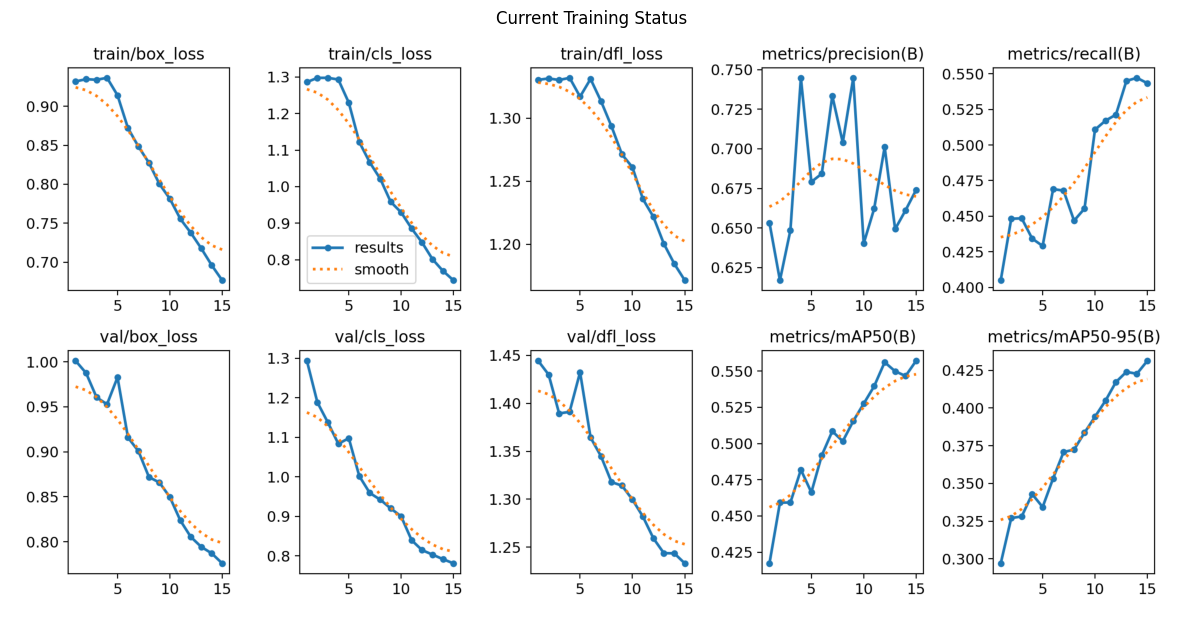

In [ ]:
# =================================================================
# 4. 결과 업데이트 및 시각화 (🔥 안전하게 수정됨)
# =================================================================
try:
    # 코랩 로컬 경로
    local_result_path = '/content/runs/detect/train_v2_upgraded'

    if os.path.exists(local_result_path):
        # 🚨 위험한 rmtree 제거! 기존 폴더를 유지한 채 변경/추가된 파일만 덮어씁니다.
        shutil.copytree(local_result_path, DRIVE_SAVE_PATH, dirs_exist_ok=True)
        print(f"\n✅ 구글 드라이브 업데이트 완료: {DRIVE_SAVE_PATH}")
    else:
        print(f"\n⚠️ 결과 폴더를 찾을 수 없습니다: {local_result_path}")
        print("👉 학습이 완료되었는지, 폴더 이름이 바뀌지 않았는지 확인하세요.")

    # 결과 차트 출력
    plt.figure(figsize=(15, 10))
    img_path = f'{DRIVE_SAVE_PATH}/results.png'

    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title("Current Training Status")
        plt.show()
    else:
        print("\n📊 아직 results.png 파일이 생성되지 않았습니다. (학습 진행 중 혹은 에폭 부족)")

except Exception as e:
    print(f"\n⚠️ 결과 처리 중 오류 발생: {e}")

In [ ]:
import shutil
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. 실제 파일이 저장된 경로 수정 (로그에 찍혔던 이름으로!)
# 기존: '/content/runs/detect/runs/detect/train'
REAL_PATH = '/content/runs/detect/runs/detect/train_v2_upgraded'
DRIVE_PATH = '/content/drive/MyDrive/food_yolo_project/train_results'

# 2. 드라이브로 강제 복사 (동일)
if os.path.exists(REAL_PATH):
    shutil.copytree(REAL_PATH, DRIVE_PATH, dirs_exist_ok=True)
    print(f"✅ 파일을 성공적으로 옮겼습니다! 위치: {DRIVE_PATH}")
else:
    # 만약 위 경로도 아니라고 나오면, 왼쪽 폴더 아이콘에서 'runs' 폴더를 직접 열어 이름을 확인해 보세요!
    print(f"❌ 경로를 찾을 수 없습니다. 현재 시도한 경로: {REAL_PATH}")

✅ 파일을 성공적으로 옮겼습니다! 위치: /content/drive/MyDrive/food_yolo_project/train_results


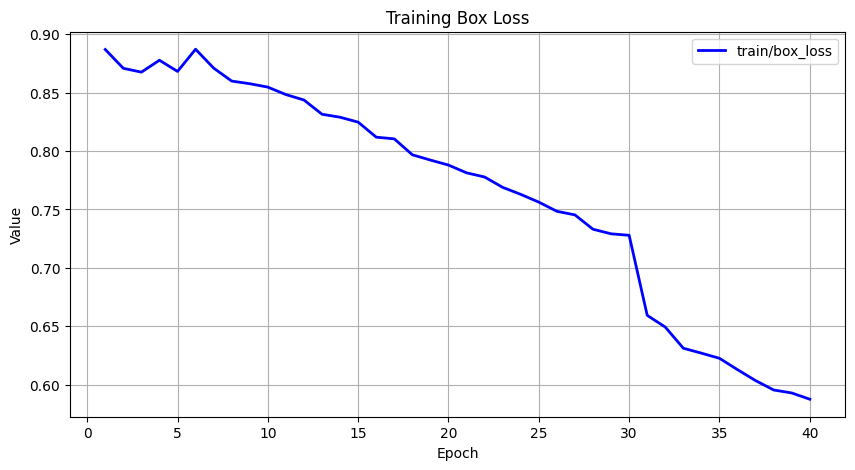

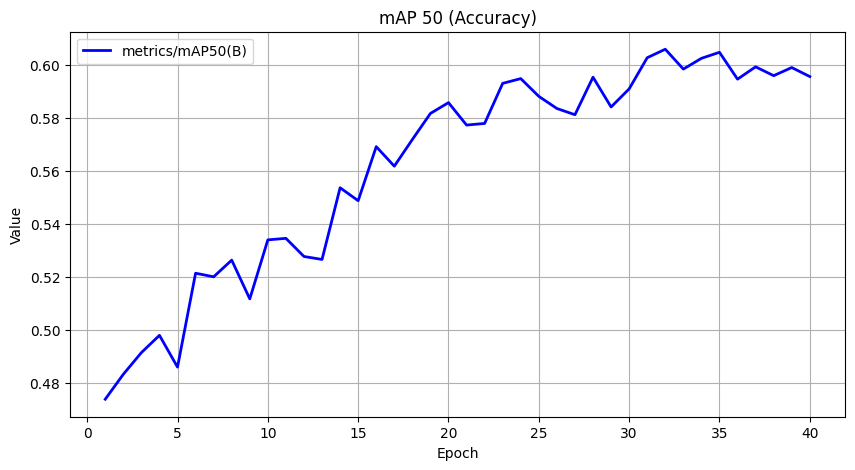

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. CSV 파일 로드
results_csv = f'{REAL_PATH}/results.csv'
df = pd.read_csv(results_csv)

# 공백 제거 (컬럼명에 공백이 있을 수 있음)
df.columns = [c.strip() for c in df.columns]

# 2. 개별 그래프 그리기 함수 정의
def plot_metric(df, metric_name, title):
    plt.figure(figsize=(10, 5))
    plt.plot(df['epoch'], df[metric_name], label=metric_name, color='blue', linewidth=2)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

# 3. 보고 싶은 것만 골라서 크게 보기
# 보고 싶은 컬럼명을 아래에서 골라 사용하세요:
# train/box_loss, train/cls_loss, metrics/precision(B), metrics/recall(B), metrics/mAP50(B) 등
plot_metric(df, 'train/box_loss', 'Training Box Loss')
plot_metric(df, 'metrics/mAP50(B)', 'mAP 50 (Accuracy)')